# 07. 임계값 튜닝 (Threshold Tuning)

## 개요
- **입력**: `val_calib.parquet` + `notebooks2/models2/06d_optuna_tuning/seed_42/subset_*.pkl`
- **평가**: 개체(디스크) 단위 / 리드타임 30일
- **TP 기준**: 디스크 생애 **최초 알람**이 `failure==1` 구간(D-1~D-30) 이내에 울린 경우
- **FP 기준**: 정상 디스크에서 알람이 1회라도 발생한 경우
- **출력**: FAR–Recall 곡선 + 운영점 테이블 (0.1 / 0.5 / 1.0 / 2.0 %) + `best_threshold.json`

> 이 노트북은 `src/` · `config/` 모듈에 의존하지 않습니다.

## § 1/5 — 경로 · 설정

In [1]:
import os, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 한글 폰트 ──────────────────────────────────
for _fn in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
    if any(_fn.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _fn; break
plt.rcParams["axes.unicode_minus"] = False

# ── 경로 ───────────────────────────────────────
# 프로젝트 루트 경로를 대화형/비대화형 실행 환경에 맞추어 강건하게 탐색
current_dir = Path(os.getcwd())
if current_dir.name == "notebooks2":
    ROOT = current_dir.parent
elif (current_dir / "notebooks2").exists():
    ROOT = current_dir
else:
    ROOT = current_dir.parent
MODEL_DIR = ROOT / "notebooks2" / "models2" / "06d_optuna_tuning" / "seed_42"
DATA_DIR  = ROOT / "data2"  / "03_splitting"

FEATURE_COLS_PATH = MODEL_DIR / "feature_cols.json"
VAL_CALIB_PATH    = DATA_DIR  / "val_calib.parquet"
CACHE_NPY         = MODEL_DIR / "val_calib_probs.npy"
THRESHOLD_JSON    = MODEL_DIR / "best_threshold.json"

# ── 파라미터 ───────────────────────────────────
N_GRID          = 1000
TARGET_FAR_CAPS = [0.001, 0.005, 0.010, 0.020]   # 0.1 / 0.5 / 1.0 / 2.0 %
SAVE_FAR_CAP    = 0.005                            # JSON 저장 기준 (0.5 %)
TARGET_COL      = "failure"
SERIAL_COL      = "serial_number"
DATE_COL        = "date"

# ── Data Path Contract ─────────────────────────
print("[Data Path Contract]")
for lbl, p in [("model_dir", MODEL_DIR), ("feature_cols", FEATURE_COLS_PATH), ("val_calib", VAL_CALIB_PATH)]:
    ok = p.exists()
    sz = f"({p.stat().st_size:,} bytes)" if ok and p.is_file() else ""
    print(f"  [{'OK' if ok else 'MISSING'}] {lbl}: {p} {sz}")
    if not ok: raise FileNotFoundError(p)
print("\n✅ 경로 확인 완료")

[Data Path Contract]
  [OK] model_dir: c:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42 
  [OK] feature_cols: c:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\feature_cols.json (386 bytes)
  [OK] val_calib: c:\Workspace\06_ML_projdect\26_1_COIN\data2\03_splitting\val_calib.parquet (244,460,369 bytes)

✅ 경로 확인 완료


## § 2/5 — 앙상블 모델 로드

In [2]:
with open(FEATURE_COLS_PATH, encoding="utf-8") as f:
    FEATURE_COLS = json.load(f)

model_paths = sorted(MODEL_DIR.glob("subset_*.pkl"))
if not model_paths:
    raise FileNotFoundError(f"subset_*.pkl 없음: {MODEL_DIR}")

print("[Model Artifact Contract]")
print(f"  model_dir    : {MODEL_DIR}")
print(f"  feature_cols : {len(FEATURE_COLS)} features")
for p in model_paths:
    print(f"  {p.name}  ({p.stat().st_size:,} bytes)")

models = []
for i, p in enumerate(model_paths):
    t0 = time.perf_counter()
    models.append(joblib.load(p))
    print(f"  로드 {i+1}/{len(model_paths)}: {p.name}  → {time.perf_counter()-t0:.1f}s")

print(f"\n✅ 모델 로드 완료: {len(models)}개")

[Model Artifact Contract]
  model_dir    : c:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42
  feature_cols : 17 features
  subset_00.pkl  (297,156 bytes)
  subset_01.pkl  (296,948 bytes)
  subset_02.pkl  (296,836 bytes)
  subset_03.pkl  (296,740 bytes)
  subset_04.pkl  (296,820 bytes)
  로드 1/5: subset_00.pkl  → 0.7s
  로드 2/5: subset_01.pkl  → 0.0s
  로드 3/5: subset_02.pkl  → 0.0s
  로드 4/5: subset_03.pkl  → 0.0s
  로드 5/5: subset_04.pkl  → 0.0s

✅ 모델 로드 완료: 5개


## § 3/5 — 데이터 로드 · 앙상블 추론 (캐시 지원)

In [3]:
print(f"🔄 데이터 로드: {VAL_CALIB_PATH}")
t0 = time.perf_counter()
df = pd.read_parquet(VAL_CALIB_PATH)
print(f"  {len(df):,}행  positives={df[TARGET_COL].sum():,}  entities={df[SERIAL_COL].nunique():,}  ({time.perf_counter()-t0:.1f}s)")

# 캐시 확인
y_prob = None
if CACHE_NPY.exists():
    cached = np.load(CACHE_NPY, mmap_mode="r")
    if len(cached) == len(df):
        print("\n♻️  캐시 로드")
        y_prob = np.array(cached)
    else:
        print(f"\n⚠️  캐시 크기 불일치 ({len(cached)} vs {len(df)}) → 재추론")
        CACHE_NPY.unlink(missing_ok=True)

if y_prob is None:
    print("\n🔄 앙상블 추론 중...")
    X = df[FEATURE_COLS].values.astype(np.float32)
    probs_list = []
    for i, m in enumerate(models):
        t0 = time.perf_counter()
        probs_list.append(m.predict_proba(X)[:, 1])
        print(f"  모델 {i+1}/{len(models)}  ({time.perf_counter()-t0:.1f}s)")
    y_prob = np.mean(probs_list, axis=0)
    np.save(CACHE_NPY, y_prob)
    print(f"  캐시 저장: {CACHE_NPY}")

print(f"\n✅ 추론 완료  prob_min={y_prob.min():.4f}  prob_max={y_prob.max():.4f}")

🔄 데이터 로드: c:\Workspace\06_ML_projdect\26_1_COIN\data2\03_splitting\val_calib.parquet
  7,670,020행  positives=17,321  entities=8,444  (0.3s)

♻️  캐시 로드

✅ 추론 완료  prob_min=0.0046  prob_max=0.7958


## § 4/5 — 개체 단위 그룹화 · 그리드 서치

**TP 판정**: 디스크 생애 **최초 알람**이 `failure==1` 구간(D-1~D-30) 안에 있으면 TP  
**FP 판정**: 정상 디스크(`is_failed==0`)에서 알람이 1회라도 발생

In [4]:
# ── 1) 개체 단위 그룹화 ──────────────────────────────────
print("🔄 개체 단위 그룹화 중...")
t0 = time.perf_counter()

df = df.copy()
df["_prob"]    = y_prob
df["_base"]    = df[SERIAL_COL].str.replace(r'_\d+$', '', regex=True)
df[DATE_COL]   = pd.to_datetime(df[DATE_COL])
df = df.sort_values(["_base", DATE_COL])

disks = []
for base_sn, grp in df.groupby("_base", sort=False):
    disks.append({
        "is_failed" : int(grp[TARGET_COL].max()),
        "probs"     : grp["_prob"].values,
        "failures"  : grp[TARGET_COL].values,   # 0/1 per row
    })

n_failed = sum(d["is_failed"] for d in disks)
n_normal = len(disks) - n_failed
print(f"  디스크 총 {len(disks):,}개  고장={n_failed:,}  정상={n_normal:,}  ({time.perf_counter()-t0:.2f}s)")

# 정상 디스크 최고 확률 사전 계산 (빠른 FP 계산)
normal_max_probs = np.array([d["probs"].max() for d in disks if not d["is_failed"]])
failed_disks     = [d for d in disks if d["is_failed"]]

# ── 2) 그리드 서치 ────────────────────────────────────────
thresholds = np.linspace(0.001, 0.999, N_GRID)
grid_rows  = []

print(f"\n🔄 그리드 서치 (N={N_GRID})")
t_grid = time.perf_counter()

for idx, T in enumerate(thresholds):
    # FP: 정상 디스크 최고 확률 >= T
    fps = int(np.sum(normal_max_probs >= T))

    # TP: 고장 디스크의 생애 최초 알람이 failure==1 구간 안에 있는 경우
    tps = 0
    for d in failed_disks:
        alarm_idx = np.where(d["probs"] >= T)[0]
        if len(alarm_idx) > 0 and d["failures"][alarm_idx[0]] == 1:
            tps += 1

    recall = tps / n_failed if n_failed > 0 else 0.0
    far    = fps / n_normal if n_normal > 0 else 0.0
    grid_rows.append({"threshold": float(T), "recall": recall, "far": far,
                      "tps": tps, "fps": fps})

    if (idx + 1) % (N_GRID // 10) == 0 or (idx + 1) == N_GRID:
        pct = 100.0 * (idx + 1) / N_GRID
        print(f"  ... {idx+1:,}/{N_GRID:,} ({pct:.1f}%) - {time.perf_counter()-t_grid:.1f}s")

df_grid = pd.DataFrame(grid_rows)
grid_csv = MODEL_DIR / "disk_grid_val_calib_30d.csv"
df_grid.to_csv(grid_csv, index=False, encoding="utf-8-sig")

# ── reports2/ 에도 복사본 저장 (07a_ 접두사 추가) ───────────
import os
os.makedirs("reports2", exist_ok=True)
df_grid.to_csv("reports2/07a_disk_grid_val_calib_30d.csv", index=False, encoding="utf-8-sig")
print("✅ 보고서 저장 완료: reports2/07a_disk_grid_val_calib_30d.csv")
print(f"\n✅ 그리드 서치 완료 → {grid_csv}")

🔄 개체 단위 그룹화 중...
  디스크 총 3,692개  고장=569  정상=3,123  (1.97s)

🔄 그리드 서치 (N=1000)
  ... 100/1,000 (10.0%) - 0.1s
  ... 200/1,000 (20.0%) - 0.2s
  ... 300/1,000 (30.0%) - 0.3s
  ... 400/1,000 (40.0%) - 0.4s
  ... 500/1,000 (50.0%) - 0.5s
  ... 600/1,000 (60.0%) - 0.6s
  ... 700/1,000 (70.0%) - 0.6s
  ... 800/1,000 (80.0%) - 0.7s
  ... 900/1,000 (90.0%) - 0.8s
  ... 1,000/1,000 (100.0%) - 0.9s
✅ 보고서 저장 완료: reports2/07a_disk_grid_val_calib_30d.csv

✅ 그리드 서치 완료 → c:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\disk_grid_val_calib_30d.csv


## § 5/5 — 운영점 도출 · 저장 · 시각화

In [5]:
# ── 운영점 테이블 출력 ────────────────────────────────────
print("## disk-level threshold  (리드타임 = 30일, 생애 최초 알람 기준)\n")
print(f"  고장 디스크: {n_failed:,}개  |  정상 디스크: {n_normal:,}개\n")

hdr = f"{'허용 오탐율':^12} | {'threshold':^10} | {'Disk FAR':^10} | {'Disk Recall':^12} | {'Precision':^10}"
sep = "-" * len(hdr)
print(sep); print(hdr); print(sep)

best_op = None
operating_points = []

for cap in TARGET_FAR_CAPS:
    sub = df_grid[df_grid["far"] <= cap]
    if sub.empty:
        print(f"  {cap*100:>6.2f}   % | {'N/A':^10} | {'N/A':^10} | {'N/A':^12} | {'N/A':^10}")
        continue
    row  = sub.sort_values("recall", ascending=False).iloc[0]
    T    = float(row["threshold"])
    far  = float(row["far"])
    rec  = float(row["recall"])
    tps  = int(row["tps"]); fps = int(row["fps"])
    prec = tps / (tps + fps) if (tps + fps) > 0 else 0.0
    print(f"  {cap*100:>6.2f}   % | {T:^10.4f} | {far*100:^9.2f}% | {rec*100:^11.2f}% | {prec*100:^9.2f}%")
    op = dict(far_cap=cap, threshold=T, disk_far=far, disk_recall=rec, precision=prec, tps=tps, fps=fps)
    operating_points.append(op)
    if abs(cap - SAVE_FAR_CAP) < 1e-9:
        best_op = op
print(sep)

# ── best_threshold.json 저장 ──────────────────────────────
if best_op is not None:
    meta = {
        "threshold"        : best_op["threshold"],
        "min_alarms"       : 1,
        "window_size"      : None,
        "horizon_days"     : 30,
        "save_far_cap"     : SAVE_FAR_CAP,
        "disk_far"         : best_op["disk_far"],
        "disk_recall"      : best_op["disk_recall"],
        "precision"        : best_op["precision"],
        "n_features"       : len(FEATURE_COLS),
        "model_files"      : [p.name for p in model_paths],
        "val_calib_path"   : str(VAL_CALIB_PATH),
        "n_failed_disks"   : n_failed,
        "n_normal_disks"   : n_normal,
        "operating_points" : operating_points,
        "created_at"       : pd.Timestamp.now().isoformat(timespec="seconds"),
    }
    with open(THRESHOLD_JSON, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    print(f"\n✅ 저장: {THRESHOLD_JSON}")
    print(f"   threshold = {best_op['threshold']:.4f}  (FAR cap {SAVE_FAR_CAP*100:.1f}%)")
else:
    print("\n⚠️  SAVE_FAR_CAP 기준 운영점 없음 → JSON 미저장")

## disk-level threshold  (리드타임 = 30일, 생애 최초 알람 기준)

  고장 디스크: 569개  |  정상 디스크: 3,123개

------------------------------------------------------------------
   허용 오탐율    | threshold  |  Disk FAR  | Disk Recall  | Precision 
------------------------------------------------------------------
    0.10   % |   0.6354   |   0.10   % |    14.94   % |   96.59  %
    0.50   % |   0.4875   |   0.48   % |    24.43   % |   90.26  %
    1.00   % |   0.4106   |   0.99   % |    27.42   % |   83.42  %
    2.00   % |   0.2937   |   1.99   % |    31.46   % |   74.27  %
------------------------------------------------------------------

✅ 저장: c:\Workspace\06_ML_projdect\26_1_COIN\notebooks2\models2\06d_optuna_tuning\seed_42\best_threshold.json
   threshold = 0.4875  (FAR cap 0.5%)


💾 Plot saved to: reports2/plots/07a_far_recall_curve_val_calib_30d.png


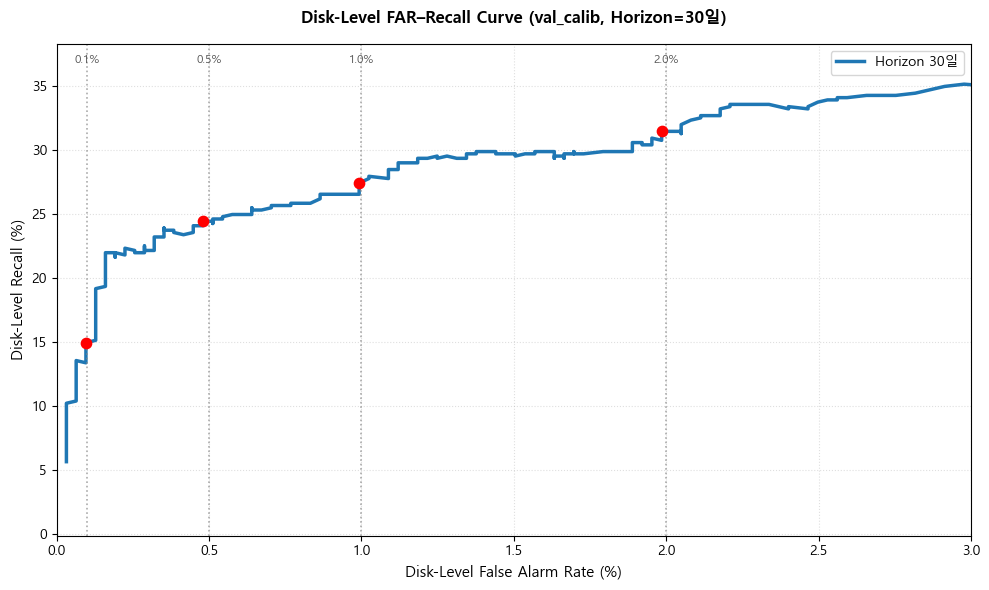

In [6]:
# ── FAR–Recall 곡선 ────────────────────────────────────────
plot_df = df_grid[df_grid["far"] > 0].sort_values("threshold", ascending=False)

plt.figure(figsize=(10, 6))
plt.plot(plot_df["far"] * 100, plot_df["recall"] * 100,
         color="#1f77b4", lw=2.5, label="Horizon 30일")

for cap in TARGET_FAR_CAPS:
    plt.axvline(cap * 100, color="#888", ls=":", alpha=0.7, lw=1.2)
    plt.text(cap * 100, plt.ylim()[1] * 0.96 if plt.ylim()[1] > 0 else 1,
             f"{cap*100:.1f}%", color="#555", fontsize=8.5, ha="center")

for op in operating_points:
    plt.scatter(op["disk_far"] * 100, op["disk_recall"] * 100, color="red", zorder=5, s=55)

plt.xlim([0.0, 3.0])
plt.xlabel("Disk-Level False Alarm Rate (%)", fontsize=11)
plt.ylabel("Disk-Level Recall (%)", fontsize=11)
plt.title("Disk-Level FAR–Recall Curve (val_calib, Horizon=30일)",
          fontsize=12, fontweight="bold", pad=15)
plt.legend(fontsize=10)
plt.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
import os
os.makedirs("reports2/plots", exist_ok=True)
plt.savefig("reports2/plots/07a_far_recall_curve_val_calib_30d.png", dpi=300)
print("💾 Plot saved to: reports2/plots/07a_far_recall_curve_val_calib_30d.png")
plt.show()

## 검증

In [7]:
print("=" * 55)
print("[검증] best_threshold.json 로드 확인")
with open(THRESHOLD_JSON, encoding="utf-8") as f:
    chk = json.load(f)

assert 0.0 < chk["threshold"] < 1.0,             "threshold 범위 이상"
assert chk["n_features"] == len(FEATURE_COLS),    "feature 개수 불일치"
assert len(chk["model_files"]) == len(model_paths), "모델 파일 개수 불일치"
assert chk["n_failed_disks"] == n_failed,          "failed disks 수 불일치"

print(f"  threshold    : {chk['threshold']:.4f}")
print(f"  disk_recall  : {chk['disk_recall']*100:.2f} %")
print(f"  disk_far     : {chk['disk_far']*100:.2f} %")
print(f"  precision    : {chk['precision']*100:.2f} %")
print(f"  n_features   : {chk['n_features']}")
print(f"  model_files  : {len(chk['model_files'])}개")
print(f"  created_at   : {chk['created_at']}")
print("\n✅ 검증 통과")
print("=" * 55)

[검증] best_threshold.json 로드 확인
  threshold    : 0.4875
  disk_recall  : 24.43 %
  disk_far     : 0.48 %
  precision    : 90.26 %
  n_features   : 17
  model_files  : 5개
  created_at   : 2026-05-30T19:42:09

✅ 검증 통과
